In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

from google.colab import drive
drive.mount('/content/drive/')

ZIP_PATH = '/content/drive/MyDrive/ecoscan_clean (1).zip'

print("Sedang mengekstrak dataset ke local runtime Colab... (Silakan tunggu)")
if os.path.exists(ZIP_PATH):
    !unzip -o -q "{ZIP_PATH}" -d /content/dataset/
    print("Ekstrak berhasil dilakukan!\n")
else:
    print("Error: File ZIP tidak ditemukan di Drive.")

DATASET_DIR = '/content/dataset'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Memuat dataset training (80%)...")
train_dataset = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

print("\nMemuat dataset validation (20%)...")
validation_dataset = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

class_names = train_dataset.class_names
print("\nClasses ditemukan:", class_names)

Mounted at /content/drive/
Sedang mengekstrak dataset ke local runtime Colab... (Silakan tunggu)
Ekstrak berhasil dilakukan!

Memuat dataset training (80%)...
Found 18638 files belonging to 7 classes.
Using 14911 files for training.

Memuat dataset validation (20%)...
Found 18638 files belonging to 7 classes.
Using 3727 files for validation.

Classes ditemukan: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Organik', 'Plastik', 'Residu']


In [12]:
class StopAt85Callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= 0.85:
            print(f"\nTarget tercapai! Val_Accuracy: {val_acc:.4f}. Menghentikan training pada epoch {epoch+1}.")
            self.model.stop_training = True

class CustomNormalizationLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomNormalizationLayer, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.cast(inputs, tf.float32) / 255.0

In [3]:
import tensorflow as tf
from tensorflow.keras import regularizers

def residual_block(input_tensor, filters):
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same',
                               kernel_regularizer=regularizers.l2(1e-4))(input_tensor)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same',
                               kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)

    shortcut = input_tensor
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, (1, 1), padding='same',
                                          kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

inputs = tf.keras.Input(shape=(224, 224, 3), name="input_layer")

x = CustomNormalizationLayer(name="custom_norm_layer")(inputs)

x = tf.keras.layers.RandomFlip("horizontal")(x)
x = tf.keras.layers.RandomRotation(0.1)(x)
x = tf.keras.layers.RandomZoom(0.1)(x)

x = tf.keras.layers.Conv2D(64, (7, 7), strides=2, padding='same',
                           kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

x = residual_block(x, 64)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = residual_block(x, 128)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = residual_block(x, 256)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation='softmax', name="output_layer")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EcoScan_Ultimate_CNN")
model.summary()

Model: "EcoScan_Ultimate_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_norm_layer   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (CustomNormalizati… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ custom_norm_laye… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ random_zoom[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 28, 28,    │          0 │ activation_2[0][

 Total params: 1,371,911 (5.23 MB)

 Trainable params: 1,369,223 (5.22 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [4]:
loss_function = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=['accuracy']
)

class StopAt85ValCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.85:
            print(f"\n[INFO] Target tercapai! Akurasi validasi: {logs.get('val_accuracy'):.4f}. Menghentikan training.")
            self.model.stop_training = True

stop_early = StopAt85ValCallback()

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='model_terbaik.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Memulai proses training boss-level...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=60,
    callbacks=[stop_early, reduce_lr, checkpoint]
)

model.load_weights('model_terbaik.keras')
print("Training selesai. Bobot terbaik (akurasi validasi tertinggi) telah dimuat ke dalam model!")

Memulai proses training boss-level...
Epoch 1/60
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2951 - loss: 2.0582
Epoch 1: val_accuracy improved from None to 0.10786, saving model to model_terbaik.keras

Epoch 1: finished saving model to model_terbaik.keras
466/466 ━━━━━━━━━━━━━━━━━━━━ 88s 159ms/step - accuracy: 0.3373 - loss: 1.9190 - val_accuracy: 0.1079 - val_loss: 1.9737 - learning_rate: 0.0010
Epoch 2/60
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.3976 - loss: 1.7938
Epoch 2: val_accuracy improved from 0.10786 to 0.49450, saving model to model_terbaik.keras

Epoch 2: finished saving model to model_terbaik.keras
466/466 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.4000 - loss: 1.7800 - val_accuracy: 0.4945 - val_loss: 1.6332 - learning_rate: 0.0010
Epoch 3/60
466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4286 - loss: 1.7193
Epoch 3: val_accuracy did not improve from 0.49450
466/466 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.4296 - los

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr_lanjutan = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Melanjutkan proses training dari titik terakhir...")
history_lanjutan = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[stop_early, reduce_lr_lanjutan]
)

Melanjutkan proses training dari titik terakhir...
Epoch 1/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 76s 148ms/step - accuracy: 0.8073 - loss: 0.6456 - val_accuracy: 0.7124 - val_loss: 0.8428 - learning_rate: 1.0000e-04
Epoch 2/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - accuracy: 0.8126 - loss: 0.6288 - val_accuracy: 0.7196 - val_loss: 0.8336 - learning_rate: 1.0000e-04
Epoch 3/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - accuracy: 0.8116 - loss: 0.6246 - val_accuracy: 0.7287 - val_loss: 0.8058 - learning_rate: 1.0000e-04
Epoch 4/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.8144 - loss: 0.6206 - val_accuracy: 0.7440 - val_loss: 0.7930 - learning_rate: 1.0000e-04
Epoch 5/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 77s 145ms/step - accuracy: 0.8141 - loss: 0.6157 - val_accuracy: 0.7379 - val_loss: 0.7908 - learning_rate: 1.0000e-04
Epoch 6/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.8223 - loss: 0.5987 - val_accuracy: 0.6896 - val_loss: 0.9219 - learning_rate: 1.0000

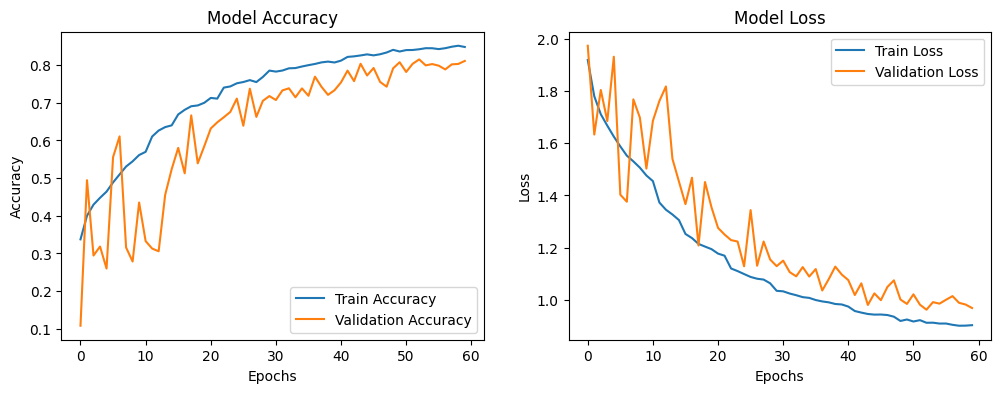

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Mencoba memuat model: model_terbaik.keras...
✅ Model berhasil dimuat sempurna!

👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari laptopmu 👇


Saving krtas.jpg to krtas (1).jpg

Memproses gambar: krtas (1).jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


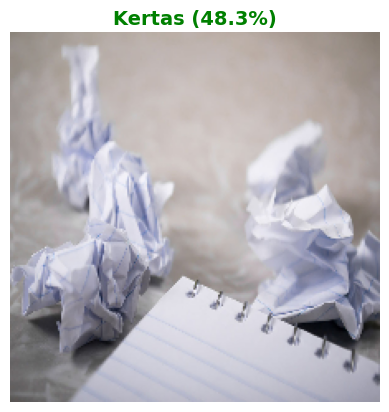

--- Detail Prediksi ---
File         : krtas (1).jpg
Jenis Sampah : Kertas
Confidence   : 48.27%



In [20]:
import numpy as np
import tensorflow as tf
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model_path = 'model_terbaik.keras'

print(f"Mencoba memuat model: {model_path}...")
try:
    loaded_model = tf.keras.models.load_model(
        model_path,
        custom_objects={'CustomNormalizationLayer': CustomNormalizationLayer}
    )
    print("✅ Model berhasil dimuat sempurna!")
except NameError:
    print("\n❌ ERROR: Class 'CustomNormalizationLayer' belum terdefinisi di memori!")
    print("👉 SOLUSI: Tolong gulir ke atas, cari dan JALANKAN (RUN) CELL yang berisi arsitektur model Wide ResNet terlebih dahulu, baru kembali jalankan cell prediksi ini.")
    raise SystemExit()
except Exception as e:
    print(f"❌ Gagal meload model: {e}")
    raise SystemExit()

print("\n👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari laptopmu 👇")
uploaded = files.upload()

class_names = ['Kaca', 'Kardus', 'Kertas' , 'Logam' , 'Organik' , 'Plastik' , 'Residu']

for fn in uploaded.keys():
    print(f"\nMemproses gambar: {fn}...")

    img = image.load_img(fn, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = loaded_model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    confidence = np.max(predictions)

    predicted_class_name = class_names[predicted_class_index]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class_name} ({confidence * 100:.1f}%)", fontsize=14, fontweight='bold', color='green')
    plt.show()

    print(f"--- Detail Prediksi ---")
    print(f"File         : {fn}")
    print(f"Jenis Sampah : {predicted_class_name}")
    print(f"Confidence   : {confidence * 100:.2f}%\n")